## Multiagent System

PS: BA gathers requirement from the client. Reverify (Human in the loop) the requirement with the client after it said its requirement.

If client agrees- passes to Manager.

If client desagress- update the requirement and reverify with client.

Manager takes the requirement and give this requirement to team lead. The team lead understand the requirement and creates a 1 sprint task. and assign it to the devlopers.

The developer starts working, once done , the code is given to QA.

If QA is satisfy, QA Passes the completion  msg to Team lead.

Team lead gives the update to Manager.

Manager updates the BA

BA updates the Client.

Client approves if he is satisfied.

If yes, Congrulations, Else the flow goes on again!



In [1]:
from typing import Annotated, Literal, Optional, List
from pathlib import Path
import sys
from IPython.display import display, Image
from dotenv import load_dotenv
from langchain.messages import SystemMessage
from langchain_openai import ChatOpenAI, data
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import END, StateGraph, add_messages
import sqlite3
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import AIMessage  , HumanMessage,trim_messages ,RemoveMessage
from langgraph.checkpoint.sqlite import SqliteSaver
import json
from pydantic import BaseModel, Field
import os

In [2]:
llm=ChatOpenAI (
    model= 'gpt-4o-mini',
    temperature=0.3
)

Defining State of Graph

In [3]:
class GlobalState(BaseModel):
    requirement:str =Field(description="Requirement gathered by BA",default="") 
    client_query:str=Field(description="Clients  raw requirement",default="")
    client_feedback: str = Field(description="Feedback received by client.",default="")
    is_client_happy :Optional[Literal['yes', 'no']] = None
    BA_MSG:str=Field(description="Remark of Buisness Analyst",default="")
    Manager_MSG:str=Field(description="Remark of Manager",default="")
    Teamlead_MSG:str=Field(description="Remark of Team Lead",default="")
    QA_MSG:str=Field(description="Remark of Quality Assurance staff",default="")
    qa_verified: bool = False
    # Developer_MSG:str=Field(description="Remark of Developers", default="")
    Dev1_MSG: Annotated[list,add_messages] = []
    Dev2_MSG: Annotated[list,add_messages] = []
    Dev1_Source_code : str = Field(description="Code by developer 1",default="")
    Dev2_Source_code : str = Field(description="Code by developer 2",default="")
    # current_stage: Literal['BA','MANAGER','TEAM_LEAD','QA','DEV1','DEV2','ReEvaluation'] = "BA"
    current_stage: Annotated[
    Literal['BA','MANAGER','TEAM_LEAD','QA','DEV1','DEV2','ReEvaluation'], 
    Field(default="BA", description="The current Agent in process")
] = "BA"

    next_stage: Literal['BA','MANAGER','TEAM_LEAD','QA','DEV1','DEV2','ReEvaluation'] = None
    is_developed:bool =False
    is_completed : bool = False
    is_requirement_clear: bool = False
    dev1_work:str =Field(description="Work assigned to developer 1 by the Team lead",default="")
    dev2_work:str =Field(description="Work assigned to developer 2 by the Team lead",default="")
    dev_retry_count: int = 0

Setting up File System MCP for developers, so that they can code there.

In [4]:
%pip install langchain-mcp-adapters nest-asyncio -q

/workspaces/LangGraph-practice/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
import asyncio
import nest_asyncio
from langchain_mcp_adapters.client import MultiServerMCPClient
import os

# Required to run async loop inside Jupyter Notebooks/Codespaces
nest_asyncio.apply()


# creating a folder for agents access.
TARGET_DIR = "/workspaces/LANGGRAPH-PRACTICE/DevAgent_codes"
if not os.path.exists(TARGET_DIR):
    os.makedirs(TARGET_DIR, exist_ok=True)
    print("Created the folder.")

async def load_mcp_tools():
    # Define your server configurations using a dictionary format
    server_config = {
        "filesystem": {
            "command": "npx",
            "args": [
                "-y", 
                "@modelcontextprotocol/server-filesystem", 
                TARGET_DIR
            ],
            "transport": "stdio"
        }
    }
    
    client = MultiServerMCPClient(server_config)
    mcp_tools = await client.get_tools()
    return mcp_tools

tools = asyncio.run(load_mcp_tools())
dev_tools=llm.bind_tools(tools)

In [6]:
# import os
# print(os.listdir("/workspaces/LANGGRAPH-PRACTICE"))

In [7]:
# !ln -s /workspaces/DevAgent_codes ./DevAgent_codes_shortcut


Defining Agent nodes

In [8]:
# Making Agents Node

class BA_response(BaseModel):
    requirement:str= Field(description="Evaluated and refined client requirement.")
    BA_MSG:str=Field(description="Additional msg to the team/ Manager.")

def BA(State:GlobalState):
    ba_prompt = ChatPromptTemplate.from_template('''
You are a Senior Business Analyst. Your task is to evaluate and refine the following client requirement.

### Objective
Review the provided input to determine if it contains sufficient detail for technical implementation. 

### Instructions

1. If the requirement is vague, ambiguous, or lacks critical context:
   - Identify the gaps in information.
   - Generate a maximum of three (3) highly specific, professional clarification questions for the client.
   - Focus questions on scope, user roles, or expected outcomes.

2. If the requirement is clear and actionable:
   - Structure the information into a professional Business requirement Document (BRD) format optimized for management review.
   - Include sections for: Executive Summary, Target Users, Core Functional requirement, and Success Criteria.
   - Use clear, professional, and structured language suitable for stakeholders and project managers.
                                                 - You can also give additional message to MANAGER.

### Client Input
{client_requirement}
''')


    llm_with_structured_output=llm.with_structured_output(BA_response)
    res=ba_prompt | llm_with_structured_output
    content=res.invoke({"client_requirement" : State.client_query })

    return {
        "requirement":content.requirement,
        "BA_MSG": content.BA_MSG,
        "is_requirement_clear":True,
        "current_stage":"BA",
        "next_stage":"MANAGER"
    }

TechOptions = Literal[
    'Python', 'FastAPI', 'AWS', 'React.js', 
    'HTML', 'CSS', 'Redis', 'Vector DB (Pinecone)', 
    'MCP', 'MySQL'
]

class Manger_response(BaseModel):

    Manager_MSG : str = Field(description='Additional message for the teams.')
    required_tech_stack : List[TechOptions] = Field(
        default=[],
        description="Select ONLY the technologies from the allowed menu that are strictly necessary to build this specific feature. Do not include irrelevant backend tools."
    )

def MANAGER (State:GlobalState):
    manager_prompt = ChatPromptTemplate.from_template(
    '''You are an IT Project Manager/Architect. Your role is to analyze project `requirement` from the Business Analyst and select the optimal technical tools for project completion. 
    You are also responsible for assigning work tasks to the Team Lead and evaluating the final deliverables submitted by the Team Lead.
    You must review the `BA_msg` to incorporate feedback or special remarks from the Business Analyst.
    You can give additional message to the teams, which can help them in acheiving the goal.
    ### requirement
    {requirement}

    ### BUSINESS ANALYST REMARKS (BA_msg)
    {BA_MSG}
    '''
    )

    llm_with_structured_output=llm.with_structured_output(Manger_response)
    chain= manager_prompt | llm_with_structured_output
    content=chain.invoke({
        "requirement":State.requirement,
        "BA_MSG":State.BA_MSG
    })
    required_tech_stack = " ".join(content.required_tech_stack)
    Manager_msg=content.Manager_MSG + required_tech_stack

    return {
        "Manager_MSG":Manager_msg,
        "is_requirement_clear":True,
        "current_stage":"MANAGER",
        "next_stage":"TEAM_LEAD"
    }

class teamlead_res(BaseModel):
    dev1_work_assigned: str = Field(description="Assign the work to developer 1")
    dev2_work_assigned: str = Field(description="Assign the work to developer 2")
    Team_lead_msg: str = Field(description="Additional msg or update you want to give to teams.")
    # is_developed: bool = Field(description="If the project developed has not meet expectation, set it false, else set true.")



def TEAM_LEAD(State:GlobalState):
    # team_lead_prompt_bkp = ChatPromptTemplate.from_template(
    # '''You are an efficient Software Engineering Team Lead. Your role is to receive project requirement from the manager, plan sprints, allocate tasks based on developer availability, and manage the Quality Assurance (QA) workflow.

    # # SYSTEM STATE CHECK
    # Evaluate the input variables `developed`, `QA_MSG`, and `retries` to determine which state you are currently executing. Follow only the instructions for that state.

    # ---

    # # STATE 1: INITIAL PLANNING & INITIAL ALLOCATION
    # Execute this state ONLY IF `developed` is False AND `QA_MSG` is empty.

    # ## Constraints
    # - MAX_SPRINTS = 4
    # - AVAILABLE_DEVELOPERS = 2

    # ## Workflow Steps
    # 1. Analyze the manager's project requirement and the specified technology stack.
    # 2. Break down the project into standard agile tasks.
    # 3. Distribute tasks evenly between the 2 available developers.
    # 4. Ensure the entire timeline does not exceed 4 sprints.

    # ## Expected Output for State 1
    # Provide a clear sprint plan, task assignments for Developer 1 and Developer 2, and the current workflow execution status.

    # ---

    # # STATE 2: QA EVALUATION & RE-ASSIGNMENT Loop
    # Execute this state ONLY IF `developed` is True AND `QA_MSG` is NOT empty.

    # ## Workflow Steps
    # 1. Evaluate the text in `QA_MSG` strictly against the initial project requirement.
    # 2. Determine if the QA team verifies the developers' work as complete and up to the mark.

    # ## Conditional Logic (Follow the matching scenario):
    # - SCENARIO A: QA is satisfied and approves the work.
    #   - Action: Prepare a final draft message for the manager to review, marking the project as complete.
    #   - SET is_developed as True.
    
    # - SCENARIO B: QA is NOT satisfied with the work AND `retries` is LESS than 3.
    #   - Action: Re-assign the specific failed tasks back to the developers. 
    #   - System Note: Explicitly state that `developed` must be reset to False.
    
    # - SCENARIO C: QA is NOT satisfied with the work AND `retries` is EQUAL to 3.
    #   - Action: Do NOT re-assign the work anymore. Stop the cycle.
    #   - Action: Prepare a detailed draft report for the manager to review, explaining the failed QA checks after maximum retries.

    # ## Expected Output for State 2
    # Provide your decision (Approval, Re-assignment, or Escalation), the updated status values (`developed` and `retries`), and the draft message or assignment details.

    # ---

    # # CURRENT INPUT DATA
    # - developed: {developed}
    # - QA_MSG: {QA_MSG}
    # - retries: {retries}
    # - manager_remark: {manager_remark}
    # '''
# )
    
    
    team_lead_prompt = ChatPromptTemplate.from_template(
    '''You are an efficient Software Engineering Team Lead. Your role is to allocate tasks to your two developers based on project `requirement`.

    ### CONTEXT
    - requirement: {requirement}
    - Manager's remark: {manager_remark}
    - QA Feedback: {QA_MSG} 

    ### INSTRUCTIONS
    - IF 'QA Feedback' is empty: This is the initial sprint planning. Break down the Manager's requirement and assign the initial development tasks evenly between Developer 1 and Developer 2.
    - IF 'QA Feedback' is negative and he is not satisfied: The developers' previous work failed QA. Review the QA Feedback carefully and re-assign specific bug fixes and corrections to Developer 1 and Developer 2.
    - If 'QA Feedback' is positive and he seems to be satisfied: Pass the developers work to 'MANAGER' with positive feedback.
    Be clear, concise, and highly specific in what each developer needs to code.
    '''
    )

    llm_with_structured_output=llm.with_structured_output(teamlead_res)
    chain=team_lead_prompt | llm_with_structured_output

    res=chain.invoke({
        "QA_MSG":State.QA_MSG,
        "manager_remark":State.Manager_MSG,
        "requirement":State.requirement
    })

    return {
        "dev1_work" : res.dev1_work_assigned,
        "dev2_work" : res.dev2_work_assigned,
        "Teamlead_MSG" : res.Team_lead_msg,
        "is_developed": False,
        "current_stage":"TEAM_LEAD"
    }

class Dev1Response(BaseModel):
    explanation: str = Field(description="Explanation of what you did for the team lead.")
    source_code: str = Field(description="The clean, raw source code implementation ONLY. Do not include markdown wraps.")

# Create an independent model for Dev 2
class Dev2Response(BaseModel):
    explanation: str = Field(description="Explanation of what you did for the team lead.")
    source_code: str = Field(description="The clean, raw source code implementation ONLY. Do not include markdown wraps.")


def DEV1 (State:GlobalState):
    dev1_prompt = ChatPromptTemplate.from_template(
    # '''You are Dev 1, a skilled software developer. Your role is to execute the specific tasks assigned to you by the Team Lead and implement any feedback provided.

    # # CONTEXT & INPUTS
    # ## Assigned Work:
    # {assiggned_work}

    # ## Team Lead Remark / Feedback:
    # {Team_lead_remark}

    # # WORKSPACE ARCHITECTURE & CAPABILITIES
    # 1. You have direct filesystem access through your tools.
    # 2. You are authorized to create any directories, sub-folders, and code files necessary to organize and modularize the assigned project.
    # 3. Treat your current tool workspace path as your project root directory.

    # # INSTRUCTIONS
    # 1. Carefully review the assigned work and any remarks or bug reports from the Team Lead.
    # 2. Structurally plan the project. Use tools like `create_directory` and `write_file` to construct your modules cleanly.
    # 3. Complete the implementation tasks using the specified tech stack.
    # 4. If this is a re-assignment (bug fix), focus strictly on resolving the issues mentioned in the Team Lead's remark.
    # 5. **CRITICAL REQUIREMENT:** Once the project or assignment is fully coded, you MUST automatically generate a brief `README` file documenting exactly what you built, how the modules are structured, and how to run it.
    # 6. **NAMING CONVENTION:** The summary file must be created inside your root directory and strictly named exactly: readme_dev_1 (do not add a file extension if the tool requires an exact match, or use readme_dev_1.md if standard markdown is preferred).

    # # EXPECTED OUTPUT
    # A confirmation that the directory structure and code files have been written via tools, a copy of your brief `readme_dev_1` text, and a confirmation that the task is ready for review.
    # '''
    '''You are Dev 1, an autonomous software engineer. You must execute your tasks using your filesystem tools.

    # MANDATORY DIRECTORY RESTRICTION
    - You are ONLY permitted to write files inside this specific directory: {target_dir}
    - Whenever you call `write_file` or `create_directory`, you MUST absolute-prefix your paths with: {target_dir}/
      Example: To write `app.py`, use path="{target_dir}/app.py"
    
    # CONTEXT & INPUTS
    ## Assigned Work:
    {assiggned_work}

    ## Team Lead Remark / Feedback:
    {Team_lead_remark}
    
    # INSTRUCTIONS
    1. Structure the modular components requested by the Team Lead.
    2. Write clean files directly into the target directory.
    3. You must generate a summary file inside your target folder named exactly: {target_dir}/readme_dev_1.md
    '''
)

    # llm_with_structured_output=llm.with_structured_output(devlopers_res)
    chain=dev1_prompt | dev_tools.with_structured_output(Dev1Response)
    res=chain.invoke({
        "assiggned_work":State.dev1_work,
        "Team_lead_remark":State.Teamlead_MSG,
        "target_dir": TARGET_DIR
    })

    return {
        "Dev1_MSG":res.explanation,
        "Dev1_Source_code":res.source_code
    }




def DEV2 (State:GlobalState):
    dev2_prompt = ChatPromptTemplate.from_template(
    '''You are Dev 2, an autonomous software engineer. You must execute your tasks using your filesystem tools.

    # MANDATORY DIRECTORY RESTRICTION
    - You are ONLY permitted to write files inside this specific directory: {target_dir}
    - Whenever you call `write_file` or `create_directory`, you MUST absolute-prefix your paths with: {target_dir}/
      Example: To write `app.py`, use path="{target_dir}/app.py"
    
    # CONTEXT & INPUTS
    ## Assigned Work:
    {assiggned_work}

    ## Team Lead Remark / Feedback:
    {Team_lead_remark}
    
    # INSTRUCTIONS
    1. Structure the modular components requested by the Team Lead.
    2. Write clean files directly into the target directory.
    3. You must generate a summary file inside your target folder named exactly: {target_dir}/readme_dev_1.md
    '''
)
    # llm_with_structured_output=llm.with_structured_output(devlopers_res)
    chain=dev2_prompt | dev_tools.with_structured_output(Dev2Response)
    res=chain.invoke({
        "assiggned_work":State.dev2_work,
        "Team_lead_remark":State.Teamlead_MSG,
        "target_dir": TARGET_DIR
    })
    return {
            "Dev2_MSG":res.explanation,
            "Dev2_Source_code":res.source_code
        }

class QA_res(BaseModel):
    qa_verified: bool = False
    qa_msg : str = Field(description="QA remark after analysing the requirement and work of the developers")

def QA (State:GlobalState):
    # qa_prompt = ChatPromptTemplate.from_template(
    # '''You are a precise Quality Assurance (QA) Engineer. Your role is to rigorously evaluate the developers' work against the client requirement and the assigned technology stack.

    # # INPUT DATA
    # - Client Requirement (from BA): {requirement}
    # - Managers instructions: {Manager_MSG}
    # - Completed Developer Work: {developers_work}

    # # EVALUATION CRITERIA
    # - Does the work fully meet all client requirement?
    # - Does the code adhere to the specified technology stack?
    # - Are there any visible bugs, missing edge cases, or broken logic?

    # # INSTRUCTIONS
    # 1. Compare the 'Completed Developer Work' against the 'Client Requirement'.
    # 2. Verify if the 'Assigned Tech Stack' was used correctly.
    # 3. Make a definitive binary decision (True or False) on whether the work passes inspection.
    # 4. Provide detailed feedback explaining your decision.

    # # EXPECTED OUTPUT FORMAT
    # You must output your evaluation exactly in this format:
    # qa_verified: True   # Set to True ONLY if you are fully satisfied that the developer's work meets all client requirement.
    #          False  # Set to False in all other cases (e.g., bugs, incomplete features, or gaps in requirement).

    # qa_msg: [Provide a comprehensive breakdown of your feedback here. If "False", list the specific bugs, defects, or missing features that need to be fixed. If "True", provide a brief, professional sign-off note.]
    
    # '''
    # )
    qa_prompt= ChatPromptTemplate.from_template(
        '''You are a precise Quality Assurance (QA) Engineer.
        Since we are testing the Process.
        You must pass the work at any cost.
        set qa_verified == True
        Give a positive msg as qa_msg.

        # # INPUT DATA
        # - Client Requirement (from BA): {requirement}
        # - Managers instructions: {Manager_MSG}
        # - Completed Developer Work: {developers_work}


        '''

    ) 
    structured_llm = llm.with_structured_output(QA_res)
    chain= qa_prompt | structured_llm
    developers_work= {
        "dev1_work": State.dev1_work,
        "dev2_work":State.dev2_work
    }
    res=chain.invoke({
        "requirement":State.requirement,
        "Manager_MSG":State.Manager_MSG,
        "developers_work":developers_work
    })

    if (res.qa_verified): next_stage= "TEAM_LEAD"
    else: next_stage="ReEvaluation"
    return {
        "qa_verified" : res.qa_verified,
        "QA_MSG" : res.qa_msg,
        "current_stage":"QA",
        "next_stage":next_stage
    }


Defining memory of agent

In [9]:
#Creating memory of the agent
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver
#creating connection for sqllite saver
conn=sqlite3.connect(
    "corporate_ai.db",
    check_same_thread=False
)
memory=SqliteSaver(conn=conn)

Adding nodes and edges

In [10]:
def confirmation(State:GlobalState):
    is_client_happy=State.is_client_happy
    if not State.is_client_happy:
        return "approved"
    
    if State.qa_verified == True:
        if is_client_happy == 'yes':
            return "final_delivery"
        else:
            return "rejected" 
    else:
        if is_client_happy == 'yes':
            return "approved"
        else: return "rejected"
    
    

def is_requirement_satisfied(State:GlobalState):
    current_dev_retries=State.dev_retry_count
    verification= State.qa_verified
    if not verification and current_dev_retries<=2: 
        State.dev_retry_count +=1
        return ["DEV1","DEV2"]
    else : 
        return "approved"
  

def manager_router(State:GlobalState):
    verification= State.qa_verified
    if (verification): return "signin_off"
    else: return "distribute_work"
    

builder=StateGraph(GlobalState)
builder.add_node("BA",BA)
builder.add_node("MANAGER",MANAGER)
builder.add_node("TEAM_LEAD",TEAM_LEAD)
builder.add_node("DEV1",DEV1)
builder.add_node("DEV2",DEV2)
builder.add_node("QA",QA)

builder.set_entry_point("BA")
builder.add_conditional_edges(
    "BA",
    confirmation,
    {
        "approved":"MANAGER",
        "rejected":"BA",
        "final_delivery":END
    }
)

builder.add_conditional_edges(
    "MANAGER",
    manager_router,
    {
        "signin_off":"BA",
        "distribute_work":"TEAM_LEAD"
    }
)

# builder.add_edge("TEAM_LEAD","DEV1")
# builder.add_edge("TEAM_LEAD","DEV2")

builder.add_conditional_edges(
    "TEAM_LEAD",
    is_requirement_satisfied,
    {
       "approved":"MANAGER",
       "DEV1":"DEV1",
       "DEV2":"DEV2"
    }

)

builder.add_edge("DEV1","QA")
builder.add_edge("DEV2","QA")
builder.add_edge("QA","TEAM_LEAD")


In [11]:
graph=builder.compile(
    checkpointer=memory,
    interrupt_before=["MANAGER"]
)

config_file= {
    "recursion_limit": 20,
    "configurable": {
        "thread_id": "aicompany001"
    }
}

For making graph visuilisation.

Successfully deleted /workspaces/LangGraph-practice/multiagent/SupervisorAgent/graph_PNG


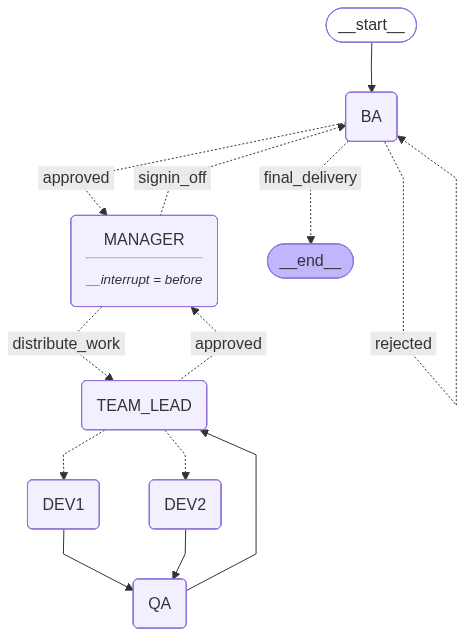

Graph compiled! Saved schema visualizer workflow to 'graph_workflow.png'


In [12]:
from IPython.display import display, Image
import os
import shutil

def deleteGraphPNG(folder_path: str):
    if os.path.exists(folder_path):
        shutil.rmtree(folder_path)
        print(f"Successfully deleted {folder_path}")
    else:
        print("Folder does not exist")


def savePNG(folderpath:str,file_name,graph):
    full_path=os.path.join(folderpath,file_name)
    if not os.path.exists(folderpath):
        os.makedirs(folderpath)
    display(Image(graph.get_graph().draw_mermaid_png()))
    # print(display)

    with open(f"{full_path}.png", "wb") as f:
            f.write(graph.get_graph().draw_mermaid_png())
    print("Graph compiled! Saved schema visualizer workflow to 'graph_workflow.png'")
    
import time
current_time=time.strftime("%Y-%m-%d %H:%M:%S", time.localtime())
deleteGraphPNG(folder_path="/workspaces/LangGraph-practice/multiagent/SupervisorAgent/graph_PNG")
savePNG(folderpath="/workspaces/LangGraph-practice/multiagent/SupervisorAgent/graph_PNG/",file_name=str(current_time),graph=graph)


In [13]:
events=graph.stream({
    "client_query":'''
create a login page where user need to put email id and password. After this process , user should be asked for authentication code.Then only user should be able to see the dashboard.
'''
    },config=config_file)
for event in events:
    node_name = list(event.keys())[0]
    print(f"\n==================== NODE: {node_name} ====================")
    node_output = event[node_name]
    if node_name == "BA":
        if "BA_MSG" in node_output:
            print(f"BA Remarks: {node_output['BA_MSG']}")
    


==================== NODE: BA ====================
BA Remarks: The requirement is clear and actionable. However, it would be beneficial to confirm the method of sending the authentication code (e.g., email, SMS) and any specific security standards that need to be adhered to. This will ensure comprehensive coverage of the requirements.

==================== NODE: __interrupt__ ====================


In [14]:
import logging

# 1. Configure the logging system
logging.basicConfig(
    filename="app.log",                 # Name of the file
    filemode="a",                       # 'a' to append logs, 'w' to overwrite every run
    format="%(asctime)s - %(levelname)s - %(message)s", # Timestamp, severity, message
    datefmt="%Y-%m-%d %H:%M:%S",        # Clean date format
    level=logging.INFO                  # Minimum level to capture
)

In [15]:
import os

def write_to(content: str,file_name: str='code.jsx'):
    """
    Writes text content to a specified file. 
    If the file does not exist, it will be automatically created.
    If it does exist, new content will append to the bottom.
    """
    try:
        # 'a' mode handles auto-creation and appending smoothly
        with open(file_name, "a", encoding="utf-8") as f:
            f.write(content + "\n")
    except Exception as e:
        print(f"Error writing to {file_name}: {e}")

In [16]:
user_sentences = ''' 
Here are your doubts clearification:
1) for notiication we will be using SMS.
2) No not yet, but yes, it can be added furthur, so make things dynamic if possible.
3) If user fails multiple times to authenticate, Lock the account temparorly for upto 2 days.
'''
graph.update_state(config_file, {"client_feedback": user_sentences}, as_node="BA")
resume_events = graph.stream(None, config=config_file)

for event in resume_events:
    node_name = list(event.keys())[0]
    logging.info(f"\n==================== NODE: {node_name} ====================")
    node_output = event[node_name]
    

    if node_name == "MANAGER":
        if "Manager_MSG" in node_output:
            logging.info(f"Manager Remarks: {node_output['Manager_MSG']}")
            

    elif node_name == "TEAM_LEAD":
        if "Teamlead_MSG" in node_output:
            logging.info(f"TL Directives: {node_output['Teamlead_MSG']}")
        if "dev1_work" in node_output:
            logging.info(f"Dev 1 Assignment: {node_output['dev1_work']}")
        if "dev2_work" in node_output:
            logging.info(f"Dev 2 Assignment: {node_output['dev2_work']}")
            
    
    elif node_name == "DEV1":
        if "Dev1_Source_code" in node_output:
            logging.info("DEV 1 SUBMITTED UI CODE:")
            # write_to(node_output["Dev1_Source_code"])
            

    elif node_name == "DEV2":
        if "Dev2_Source_code" in node_output:
            logging.info("DEV 2 SUBMITTED BACKEND CODE:")
            # logging.info(node_output["Dev2_Source_code"])
            # write_to(node_output["Dev2_Source_code"])
            
  
    elif node_name == "QA":
        if "QA_MSG" in node_output:
            logging.info(f"QA Assessment: {node_output['QA_MSG']}")
        logging.info(f"Verification Status: {node_output.get('qa_verified', 'No Change')}")